Loaded model from policy_model.pth for evaluation.
Starting evaluation...
Episode 1000: Reward/Bet Ratio = -3.98%
Episode 2000: Reward/Bet Ratio = -2.86%
Episode 3000: Reward/Bet Ratio = -2.36%
Episode 4000: Reward/Bet Ratio = -2.69%
Episode 5000: Reward/Bet Ratio = -2.93%
Episode 6000: Reward/Bet Ratio = -2.85%
Episode 7000: Reward/Bet Ratio = -3.59%
Episode 8000: Reward/Bet Ratio = -2.87%
Episode 9000: Reward/Bet Ratio = -3.26%
Episode 10000: Reward/Bet Ratio = -3.04%
Episode 11000: Reward/Bet Ratio = -2.83%
Episode 12000: Reward/Bet Ratio = -2.99%
Episode 13000: Reward/Bet Ratio = -3.21%
Episode 14000: Reward/Bet Ratio = -3.20%
Episode 15000: Reward/Bet Ratio = -3.12%
Episode 16000: Reward/Bet Ratio = -3.27%
Episode 17000: Reward/Bet Ratio = -3.25%
Episode 18000: Reward/Bet Ratio = -3.27%
Episode 19000: Reward/Bet Ratio = -3.37%
Episode 20000: Reward/Bet Ratio = -3.37%
Episode 21000: Reward/Bet Ratio = -3.33%
Episode 22000: Reward/Bet Ratio = -3.07%
Episode 23000: Reward/Bet Ratio =

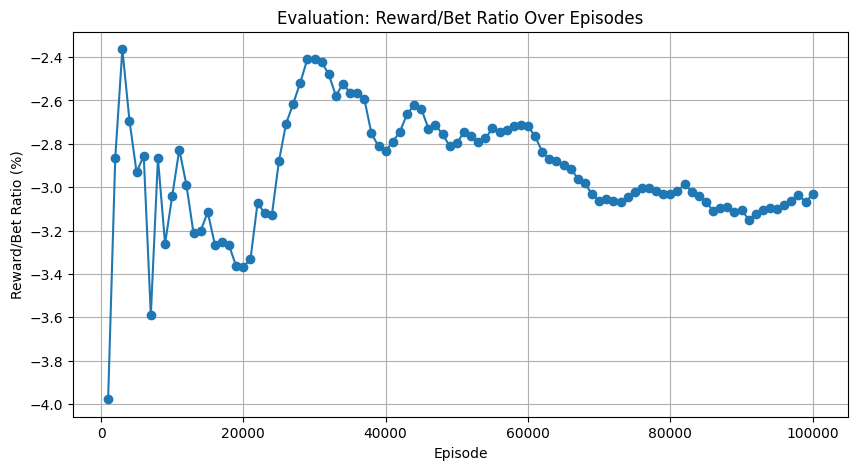

In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import copy
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import random
import math
import matplotlib.pyplot as plt
from gymnasium.wrappers import RecordEpisodeStatistics

# ----------------------------
# Policy Network Definition with Combined Action Selection and Action Masking
# ----------------------------
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim=14, hidden_dim=64, output_dim=4):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        logits = self.fc3(x)
        return logits

    def _apply_mask(self, state, logits):
        """
        Masks out double down (index 2) and surrender (index 3) logits when the first-move flag is 0.
        The first-move flag is assumed to be at index 3 in the state.
        """
        # If state is batched
        if len(state.shape) == 2:
            # Get first_move flags (1 if allowed, 0 if not)
            first_move_flags = state[:, 3]  # shape: [batch]
            # Expand to match logits dimensions
            mask = (first_move_flags.unsqueeze(1) == 0).expand_as(logits)
            # Create a mask for illegal actions (only mask actions 2 and 3)
            action_mask = torch.zeros_like(logits, dtype=torch.bool)
            action_mask[:, 2] = True
            action_mask[:, 3] = True
            final_mask = mask & action_mask
            logits = logits.masked_fill(final_mask, -1e9)
        else:
            # Single sample state (1D tensor)
            if state[3] == 0:
                logits[2] = -1e9
                logits[3] = -1e9
        return logits

    def get_log_probs(self, states, actions):
        logits = self.forward(states)
        logits = self._apply_mask(states, logits)
        probs = F.softmax(logits, dim=-1)
        dist = torch.distributions.Categorical(probs)
        log_probs = dist.log_prob(actions)
        return log_probs

    def select_action(self, state, deterministic=False):
        if not torch.is_tensor(state):
            state = torch.tensor(state, dtype=torch.float32)
        if len(state.shape) == 1:
            state = state.unsqueeze(0)
        logits = self.forward(state)
        logits = self._apply_mask(state, logits)
        probs = F.softmax(logits, dim=-1)
        if deterministic:
            action = torch.argmax(probs, dim=-1).item()
        else:
            dist = torch.distributions.Categorical(probs)
            action = dist.sample().item()
        return action

    def copy(self):
        return copy.deepcopy(self)

def initialize_policy_network():
    return PolicyNetwork(input_dim=14, hidden_dim=64, output_dim=4)

# ----------------------------
# Blackjack Environment with Card Counting & First-Move Flag
# ----------------------------
class BlackjackEnvCountingFirstMove(gym.Env):
    """
    Custom Blackjack environment with card counting and a first-move flag.

    State (MultiDiscrete):
      [player_sum, usable_ace, dealer_card, is_first_move, cnt_A, cnt_2, ..., cnt_9, cnt_10group]

      - player_sum: Sum of player's hand (0 to 31)
      - usable_ace: 0 (no usable ace) or 1 (usable ace exists)
      - dealer_card: Dealer's face-up card (1 for Ace, 2–10 for number cards)
      - is_first_move: 1 if it's the first decision of the episode, 0 otherwise.
      - cnt_A: Count for Ace (0–4)
      - cnt_2 to cnt_9: Count for cards 2 through 9 (each 0–4)
      - cnt_10group: Count for 10, Jack, Queen, King (0–16)

    Actions (Discrete(4)):
      0: HIT      – Request another card.
      1: STK      – Stand.
      2: DBL      – Double Down (allowed only on the first move).
      3: SUR      – Surrender (allowed only on the first move).

    On moves after the first, only HIT (0) and STK (1) are allowed.
    """
    def __init__(self, payout_blackjack=1.5, deck_threshold=15):
        super(BlackjackEnvCountingFirstMove, self).__init__()
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.MultiDiscrete([32, 2, 11, 2] + [5]*9 + [17])
        self.payout_blackjack = payout_blackjack
        self.base_bet = 1.0
        self.deck_threshold = deck_threshold
        self._init_deck()
        self.reset()
        
    def _init_deck(self):
        self.deck = []
        self.deck += ['A'] * 4
        for card in range(2, 10):
            self.deck += [str(card)] * 4
        self.deck += ['10'] * 16
        random.shuffle(self.deck)
        self.card_counts = {'A': 0}
        for card in range(2, 10):
            self.card_counts[str(card)] = 0
        self.card_counts['10'] = 0
        
    def _draw_card(self):
        if len(self.deck) == 0:
            self._init_deck()
        card = self.deck.pop()
        if card == 'A':
            self.card_counts['A'] = min(self.card_counts['A'] + 1, 4)
        elif card == '10':
            self.card_counts['10'] = min(self.card_counts['10'] + 1, 16)
        else:
            self.card_counts[card] = min(self.card_counts[card] + 1, 4)
        return card
    
    def _hand_value(self, hand):
        total = 0
        ace_count = 0
        for card in hand:
            if card == 'A':
                total += 1
                ace_count += 1
            else:
                total += int(card)
        usable_ace = 0
        if ace_count > 0 and total + 10 <= 21:
            total += 10
            usable_ace = 1
        return total, usable_ace
    
    def _card_value(self, card):
        return 1 if card == 'A' else int(card)
    
    def _get_observation(self):
        player_sum, usable_ace = self._hand_value(self.player_hand)
        dealer_face_up = self.dealer_hand[0]
        dealer_card_val = self._card_value(dealer_face_up)
        first_move_flag = 1 if self.first_move else 0
        counts = [self.card_counts['A']]
        for card in range(2, 10):
            counts.append(self.card_counts[str(card)])
        counts.append(self.card_counts['10'])
        obs = np.array([player_sum, usable_ace, dealer_card_val, first_move_flag] + counts, dtype=np.int32)
        return obs
    
    def reset(self, seed=None, options=None):
        self.first_move = True
        self.done = False
        self.natural_blackjack = False
        if len(self.deck) < self.deck_threshold:
            self._init_deck()
        self.player_hand = [self._draw_card(), self._draw_card()]
        self.dealer_hand = [self._draw_card(), self._draw_card()]
        player_total, _ = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        if player_total == 21:
            self.reward = self.payout_blackjack * self.base_bet if dealer_total != 21 else 0.0
            self.natural_blackjack = True
        else:
            self.reward = 0.0
        return self._get_observation(), {}
    
    def step(self, action):
        if self.natural_blackjack:
            self.natural_blackjack = False
            self.done = True
            return self._get_observation(), self.reward, True, False, {"bet": 1.0}

        if self.done:
            return self._get_observation(), 0.0, True, False, {}
        
        if not self.first_move and action in [2, 3]:
            self.done = True
            return self._get_observation(), -1.0, True, False, {"illegal_action": True}
        
        if action == 0:  # HIT
            card = self._draw_card()
            self.player_hand.append(card)
            player_total, _ = self._hand_value(self.player_hand)
            reward = -self.base_bet if player_total > 21 else 0.0
            self.first_move = False
            return self._get_observation(), reward, player_total > 21, False, {}
        
        elif action == 1:  # STAND
            reward = self._dealer_play()
            self.done = True
            return self._get_observation(), reward, True, False, {}
        
        elif action == 2:  # DOUBLE DOWN
            self.first_move = False
            card = self._draw_card()
            self.player_hand.append(card)
            player_total, _ = self._hand_value(self.player_hand)
            if player_total > 21:
                reward = -2 * self.base_bet
                self.done = True
                return self._get_observation(), reward, True, False, {}
            reward = self._dealer_play(double_down=True)
            self.done = True
            return self._get_observation(), reward, True, False, {}
        
        elif action == 3:  # SURRENDER
            self.first_move = False
            self.done = True
            reward = -0.5 * self.base_bet
            return self._get_observation(), reward, True, False, {}
        
        else:
            self.done = True
            return self._get_observation(), -1.0, True, False, {"illegal_action": True}
    
    def _dealer_play(self, double_down=False):
        player_total, _ = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        while dealer_total < 17:
            card = self._draw_card()
            self.dealer_hand.append(card)
            dealer_total, _ = self._hand_value(self.dealer_hand)
        bet = self.base_bet * (2 if double_down else 1)
        if dealer_total > 21:
            return bet
        elif dealer_total > player_total:
            return -bet
        elif dealer_total < player_total:
            return bet
        else:
            return 0.0
    
    def render(self, mode='human'):
        player_total, usable = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        print(f"Player hand: {self.player_hand} (Total: {player_total}, Usable Ace: {usable})")
        print(f"Dealer hand: {self.dealer_hand} (Total: {dealer_total})")
        print("Card counts:", self.card_counts)
        print("First move:", self.first_move)

def initialize_environment():
    return BlackjackEnvCountingFirstMove()

# ----------------------------
# Custom Wrapper to Attach Bet Info
# ----------------------------
class BetInfoWrapper(gym.Wrapper):
    def __init__(self, env):
        super(BetInfoWrapper, self).__init__(env)
    
    def step(self, action):
        self.last_action = action
        obs, reward, terminated, truncated, info = self.env.step(action)
        if terminated or truncated:
            info["bet"] = 2.0 if self.last_action == 2 else 1.0
        return obs, reward, terminated, truncated, info

# ----------------------------
# Custom Callback for Training Metrics
# ----------------------------
class BaseCallback:
    def __init__(self, verbose=0):
        self.verbose = verbose
        self.locals = {}

    def _on_step(self) -> bool:
        return True

class TrainingMetricsCallback(BaseCallback):
    def __init__(self, print_freq=100_000, verbose=0):
        super(TrainingMetricsCallback, self).__init__(verbose)
        self.print_freq = print_freq
        self.total_reward = 0.0
        self.total_bet = 0.0
        self.episode_count = 0
        self.episode_history = []
        self.ratio_history = []
    
    def _on_step(self) -> bool:
        infos = self.locals.get("infos", None)
        if infos is not None and "episode" in infos:
            self.episode_count += 1
            self.total_reward += float(infos["episode"]["r"].item())
            self.total_bet += float(infos.get("bet", 1.0))
            if self.episode_count % self.print_freq == 0:
                ratio = (float(self.total_reward) / float(self.total_bet) * 100.0) if self.total_bet > 0 else 0.0
                print(f"Episode: {self.episode_count}, Total Reward: {self.total_reward:.2f}, Total Bet: {self.total_bet:.2f}, Reward/Bet Ratio: {ratio:.2f}%")
                self.episode_history.append(self.episode_count)
                self.ratio_history.append(ratio)
        return True

# ----------------------------
# Evaluation: Load the Model and Run Evaluation Episodes
# ----------------------------
save_path = "policy_model.pth"
checkpoint = torch.load(save_path, map_location=torch.device("cpu"))
loaded_model = initialize_policy_network()
loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()
print(f"Loaded model from {save_path} for evaluation.")

eval_env = initialize_environment()
eval_env = BetInfoWrapper(eval_env)
eval_env = RecordEpisodeStatistics(eval_env)

num_eval_episodes = 100_000
reward_history = []
bet_history = []
ratio_history_eval = []
episode_x = []

wins = 0
draws = 0
losses = 0

print("Starting evaluation...")
cnt = 0
for episode in range(1, num_eval_episodes + 1):
    obs, _ = eval_env.reset()
    episode_reward = 0
    episode_bet = 0
    done = False
    while not done:
        action = loaded_model.select_action(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        episode_reward += reward
        episode_bet += info.get("bet", 1)
        done = terminated or truncated
    if episode_reward > 1:
        cnt += 1
    reward_history.append(episode_reward)
    bet_history.append(episode_bet)
    if episode_reward > 0:
        wins += 1
    elif episode_reward == 0:
        draws += 1
    else:
        losses += 1
    if episode % 1000 == 0:
        total_reward = np.sum(reward_history)
        total_bet = np.sum(bet_history)
        ratio = (total_reward / total_bet * 100) if total_bet > 0 else 0.0
        ratio_history_eval.append(ratio)
        episode_x.append(episode)
        print(f"Episode {episode}: Reward/Bet Ratio = {ratio:.2f}%")

win_percent = wins / num_eval_episodes * 100
draw_percent = draws / num_eval_episodes * 100
loss_percent = losses / num_eval_episodes * 100
avg_reward_eval = (np.sum(reward_history) / np.sum(bet_history) * 100) if np.sum(bet_history) > 0 else 0.0

print("\nFinal Evaluation Results:")
print(f"Win %: {win_percent:.2f}%")
print(f"Draw %: {draw_percent:.2f}%")
print(f"Loss %: {loss_percent:.2f}%")
print(f"Average Reward per Bet (%): {avg_reward_eval:.2f}%")
print(f"cnt {cnt}")

plt.figure(figsize=(10, 5))
plt.title("Evaluation: Reward/Bet Ratio Over Episodes")
plt.xlabel("Episode")
plt.ylabel("Reward/Bet Ratio (%)")
plt.grid(True)
plt.show()

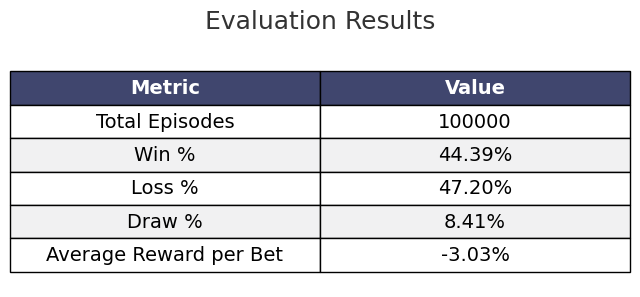

In [ ]:
# Prepare table data
table_data = [
    ["Total Episodes", num_eval_episodes],
    ["Win %", f"{win_percent:.2f}%"],
    ["Loss %", f"{loss_percent:.2f}%"],
    ["Draw %", f"{draw_percent:.2f}%"],
    ["Average Reward per Bet", f"{avg_reward_eval:.2f}%"]
]

# Create a figure and a single subplot
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')  # Turn off the axis

# Create the table and customize it
table = ax.table(cellText=table_data, colLabels=["Metric", "Value"],
                 cellLoc='center', loc='center')

# Adjust table style
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 2)

# Color the header and rows for a beautiful look
for (row, col), cell in table.get_celld().items():
    if row == 0:  # Header row
        cell.set_facecolor("#40466e")
        cell.set_text_props(color="w", weight="bold")
    else:
        # Alternate row colors for a more colorful effect
        if row % 2 == 0:
            cell.set_facecolor("#f1f1f2")
        else:
            cell.set_facecolor("#ffffff")

# Set a title with custom styling
plt.title("Evaluation Results", fontsize=18, color="#333333", pad=20)

plt.show()

[-2.  -1.  -0.5  0.   1.   1.5  2. ]


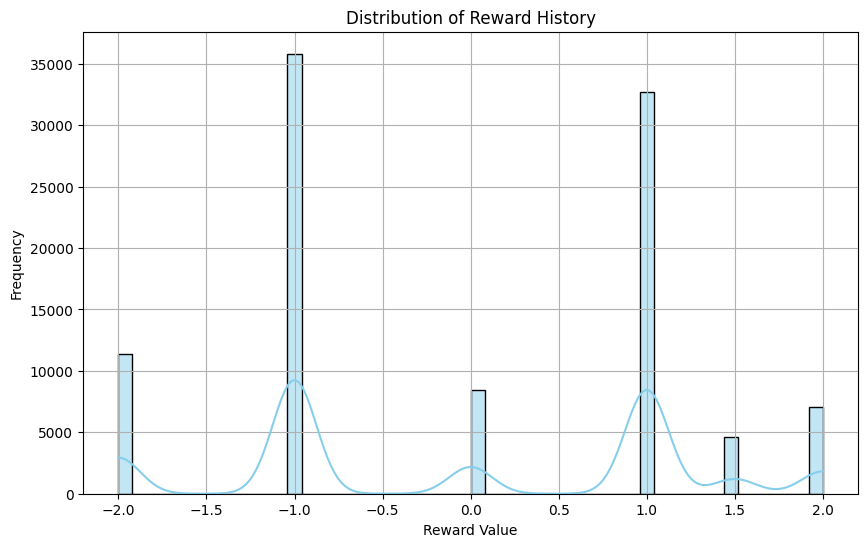

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert to NumPy array for unique values
unique_values = np.sort(np.unique(reward_history))
print(unique_values)

plt.figure(figsize=(10, 6))
sns.histplot(reward_history, bins=50, kde=True, color='skyblue', edgecolor='black')

plt.title('Distribution of Reward History')
plt.xlabel('Reward Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()